# Urban Demand Forecasting — RQ4 

This standalone notebook implements **RQ4** from the shared-mobility demand forecasting thesis proposal:

> Can contextual forecasting models better capture abrupt demand shifts caused by weather variability, holiday effects, and demand spikes?

The notebook is Kaggle-ready and auto-fetches the UCI Bike Sharing Dataset if `hour.csv` is not already available. Turn **Internet = On** in Kaggle Notebook Settings.

Thesis-ready outputs generated by this notebook:
- 4 PDF figures with academic titles and interpretation notes
- 3 CSV tables with best-model markers and thesis-safe interpretation columns
- a final ZIP file containing all RQ4 outputs

Important thesis interpretation note: RQ4 should **not** claim that the Full Cross-Modal Fusion model is best for every shock type. The thesis-safe conclusion is that **contextual modeling improves responsiveness under abrupt shifts, but the best contextual combination depends on the shock scenario**.



In [4]:
RQ = 'RQ4'

# ============================================================
# Common setup: auto-fetch dataset, preprocessing, metrics, models
# ============================================================
import os, glob, zipfile, urllib.request, warnings, shutil, math, json
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Thesis-ready plotting defaults: larger fonts, clean PDF export, readable axes.
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RQ = globals().get('RQ', 'RQ')
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
OUTPUT_DIR = OUTPUT_DIR / f'urban_demand_{RQ}_outputs'
FIG_DIR = OUTPUT_DIR / 'figures_pdf'
TAB_DIR = OUTPUT_DIR / 'tables_csv'
for d in [OUTPUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Output directory:', OUTPUT_DIR)

def section(title):
    print('\n' + '='*90)
    print(title)
    print('='*90)

def save_table(df, name):
    path = TAB_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    display(df.head(20))
    return path

def save_fig(name):
    path = FIG_DIR / f'{name}.pdf'
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path

def find_or_download_hour_csv():
    candidates = []
    search_roots = ['/kaggle/input', '/kaggle/working', str(Path.cwd()), '/mnt/data']
    for root in search_roots:
        if Path(root).exists():
            candidates.extend(glob.glob(os.path.join(root, '**', 'hour.csv'), recursive=True))
    if candidates:
        print('Found hour.csv:', candidates[0])
        return candidates[0]

    print('hour.csv not found. Downloading UCI Bike Sharing Dataset...')
    url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
    zip_path = OUTPUT_DIR / 'bike_sharing_dataset.zip'
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(OUTPUT_DIR / 'uci_bike_sharing')
        found = glob.glob(str(OUTPUT_DIR / 'uci_bike_sharing' / '**' / 'hour.csv'), recursive=True)
        if not found:
            raise FileNotFoundError('Downloaded zip did not contain hour.csv')
        print('Downloaded and extracted:', found[0])
        return found[0]
    except Exception as e:
        raise RuntimeError(
            'Could not fetch hour.csv automatically. On Kaggle, enable Internet in Notebook Settings, '
            'or add a dataset containing UCI Bike Sharing hour.csv. Original error: ' + str(e)
        )

def load_bike_data():
    hour_path = find_or_download_hour_csv()
    df = pd.read_csv(hour_path)
    df['dteday'] = pd.to_datetime(df['dteday'])
    df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')
    df = df.sort_values('datetime').reset_index(drop=True)
    print('Loaded shape:', df.shape)
    print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
    return df

def build_features(raw):
    df = raw.copy().sort_values('datetime').reset_index(drop=True)
    # Demand regimes aligned with the proposal: commute, leisure, weekend, holiday, severe weather, mixed.
    commute = (df['workingday'].eq(1)) & (df['hr'].isin([7,8,9,16,17,18,19]))
    leisure = (df['hr'].between(10,20)) & ((df['weekday'].isin([0,6])) | (df['holiday'].eq(1)))
    severe = df['weathersit'].ge(3)
    conditions = [severe, df['holiday'].eq(1), commute, leisure, df['weekday'].isin([0,6])]
    labels = ['Severe Weather', 'Holiday', 'Commute', 'Leisure', 'Weekend']
    df['regime'] = np.select(conditions, labels, default='Mixed Regime')

    # Transparent proxy neighborhood semantics because UCI has no station / POI metadata.
    # For a final thesis, replace this block with real station-level POI / land-use metadata.
    df['neighborhood_type'] = np.select(
        [commute & df['hr'].isin([7,8,9]), commute & df['hr'].isin([16,17,18,19]), leisure & df['season'].isin([2,3]), df['hr'].between(10,15) & df['workingday'].eq(1), severe],
        ['CBD', 'Residential', 'Tourist', 'University', 'Transit Hub'],
        default='Mixed-use'
    )
    # Pseudo-stations to enable cross-station and neighborhood experiments on UCI.
    df['station_id'] = (df['neighborhood_type'].astype('category').cat.codes * 10 + (df['hr'] // 4)).astype(int)
    df['station_id'] = 'S' + df['station_id'].astype(str).str.zfill(2)

    # Neighborhood feature proxies created from available temporal/weather indicators.
    nmap = {
        'CBD':          [0.20, 0.85, 0.95, 0.15, 0.25, 0.90],
        'Residential':  [0.90, 0.25, 0.30, 0.20, 0.15, 0.45],
        'University':   [0.35, 0.45, 0.30, 0.95, 0.30, 0.60],
        'Tourist':      [0.25, 0.55, 0.40, 0.25, 0.95, 0.65],
        'Transit Hub':  [0.35, 0.65, 0.55, 0.20, 0.35, 1.00],
        'Mixed-use':    [0.50, 0.55, 0.50, 0.45, 0.45, 0.65]
    }
    cols = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
    for j,c in enumerate(cols):
        df[c] = df['neighborhood_type'].map(lambda x: nmap[x][j]).astype(float)

    # Time encodings
    df['hr_sin'] = np.sin(2*np.pi*df['hr']/24)
    df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)
    df['weekday_sin'] = np.sin(2*np.pi*df['weekday']/7)
    df['weekday_cos'] = np.cos(2*np.pi*df['weekday']/7)
    df['month'] = df['datetime'].dt.month
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['is_commute'] = commute.astype(int)
    df['is_weekend'] = df['weekday'].isin([0,6]).astype(int)

    for lag in [1,2,3,6,12,24,48,168]:
        df[f'lag_{lag}'] = df['cnt'].shift(lag)
    for win in [3,6,24,168]:
        df[f'roll_mean_{win}'] = df['cnt'].shift(1).rolling(win).mean()
        df[f'roll_std_{win}'] = df['cnt'].shift(1).rolling(win).std()
    df['diff_1'] = df['cnt'].diff(1).shift(1)
    df['diff_24'] = df['cnt'].diff(24).shift(1)
    df = df.dropna().reset_index(drop=True)
    return df

RAW_DF = load_bike_data()
DATA = build_features(RAW_DF)
print('Feature-ready shape:', DATA.shape)

TARGET = 'cnt'
base_temporal = ['hr','hr_sin','hr_cos','weekday','weekday_sin','weekday_cos','month_sin','month_cos', 'season', 'yr']
weather_features = ['temp','atemp','hum','windspeed','weathersit']
calendar_features = ['holiday','workingday','is_weekend','is_commute']
lag_features = [c for c in DATA.columns if c.startswith('lag_') or c.startswith('roll_') or c.startswith('diff_')]
neighborhood_features = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
cat_features = ['neighborhood_type','regime']

FEATURE_SETS = {
    'Historical Average': [],
    'Temporal Only': base_temporal + lag_features,
    'Temporal + Weather': base_temporal + lag_features + weather_features,
    'Temporal + Calendar': base_temporal + lag_features + calendar_features,
    'Temporal + Neighborhood': base_temporal + lag_features + neighborhood_features + ['neighborhood_type'],
    'Weather + Calendar': base_temporal + lag_features + weather_features + calendar_features,
    'Full Cross-Modal Fusion': base_temporal + lag_features + weather_features + calendar_features + neighborhood_features + ['neighborhood_type']
}

def time_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    train_end = int(n*train_frac)
    val_end = int(n*(train_frac+val_frac))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

TRAIN, VAL, TEST = time_split(DATA)
print('Train/Val/Test:', TRAIN.shape, VAL.shape, TEST.shape)


def make_preprocessor(features):
    numeric = [f for f in features if f not in ['neighborhood_type','regime','station_id']]
    categorical = [f for f in features if f in ['neighborhood_type','regime','station_id']]
    transformers = []
    if numeric:
        transformers.append(('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical))
    return ColumnTransformer(transformers, remainder='drop')


def build_model(model_name='rf', features=None):
    if features is None:
        features = FEATURE_SETS['Full Cross-Modal Fusion']
    if model_name == 'ridge':
        reg = Ridge(alpha=2.0)
    elif model_name == 'gbr':
        reg = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=160, learning_rate=0.05, max_depth=3)
    elif model_name == 'extra':
        reg = ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    elif model_name == 'xgb' and HAS_XGB:
        reg = XGBRegressor(random_state=RANDOM_STATE, n_estimators=220, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', n_jobs=-1)
    else:
        reg = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    return Pipeline([('prep', make_preprocessor(features)), ('model', reg)])


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    denom = np.sum(np.abs(y_true)) + 1e-9
    wape = float(np.sum(np.abs(y_true-y_pred))/denom*100)
    peak_threshold = np.quantile(y_true, 0.90)
    mask = y_true >= peak_threshold
    peak_mae = float(mean_absolute_error(y_true[mask], y_pred[mask])) if mask.any() else np.nan
    return {'RMSE':rmse, 'MAE':mae, 'WAPE (%)':wape, 'Peak-MAE':peak_mae}


def historical_average_predict(train_df, test_df, group_cols=['hr','weekday']):
    avg = train_df.groupby(group_cols)[TARGET].mean().reset_index().rename(columns={TARGET:'pred'})
    tmp = test_df[group_cols].merge(avg, on=group_cols, how='left')['pred']
    fallback = train_df[TARGET].mean()
    return tmp.fillna(fallback).values


def fit_predict_variant(name, train_df=TRAIN, test_df=TEST, model_name='rf'):
    if name == 'Historical Average':
        pred = historical_average_predict(train_df, test_df)
        return None, pred
    feats = FEATURE_SETS[name]
    pipe = build_model(model_name=model_name, features=feats)
    pipe.fit(train_df[feats], train_df[TARGET])
    pred = pipe.predict(test_df[feats])
    pred = np.clip(pred, 0, None)
    return pipe, pred


def evaluate_variants(variants=None, model_name='rf', train_df=TRAIN, test_df=TEST):
    if variants is None:
        variants = list(FEATURE_SETS.keys())
    rows = []
    preds = {}
    models = {}
    for name in variants:
        model, pred = fit_predict_variant(name, train_df=train_df, test_df=test_df, model_name=model_name)
        row = {'Model': name, **metrics(test_df[TARGET], pred)}
        rows.append(row); preds[name]=pred; models[name]=model
    perf = pd.DataFrame(rows).sort_values('RMSE')
    return perf, preds, models


def zip_outputs(zip_name=None):
    if zip_name is None:
        zip_name = f'urban_demand_{RQ}_outputs.zip'
    zip_path = OUTPUT_DIR.parent / zip_name
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for p in OUTPUT_DIR.rglob('*'):
            if p.is_file():
                z.write(p, p.relative_to(OUTPUT_DIR.parent))
    print('Final ZIP created:', zip_path)
    return zip_path


Output directory: /kaggle/working/urban_demand_RQ4_outputs
Found hour.csv: /kaggle/working/urban_demand_RQ4_outputs/uci_bike_sharing/hour.csv
Loaded shape: (17379, 18)
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Feature-ready shape: (17211, 54)
Train/Val/Test: (12047, 54) (2582, 54) (2582, 54)



RQ4 — Thesis-ready abrupt demand-shift responsiveness analysis
Shock windows detected:


,Shock Scenario,Samples
0,Normal,1858
1,Demand spike/change-point,246
2,Heatwave proxy,203
3,Sudden/adverse weather,186
4,Public holiday,89


Saved table: /kaggle/working/urban_demand_RQ4_outputs/tables_csv/RQ4_Table_1_forecast_accuracy_under_shock_scenarios_thesis_ready.csv


,Shock Scenario,Samples,Model,RMSE,MAE,WAPE (%),Peak-MAE,Best Model by WAPE,Best in Scenario,Thesis-safe interpretation
0,Demand spike/change-point,246,Weather + Calendar,115.523751,89.327377,16.394991,168.941300,Weather + Calendar,Yes,Abrupt demand spikes are handled best by the l...
1,Demand spike/change-point,246,Temporal + Weather,116.582557,89.756536,16.473758,167.949614,Weather + Calendar,No,Abrupt demand spikes are handled best by the l...
2,Demand spike/change-point,246,Full Cross-Modal Fusion,116.015641,89.978250,16.514451,172.907654,Weather + Calendar,No,Abrupt demand spikes are handled best by the l...
3,Demand spike/change-point,246,Temporal Only,121.205971,92.862152,17.043758,200.391387,Weather + Calendar,No,Abrupt demand spikes are handled best by the l...
4,Heatwave proxy,203,Weather + Calendar,57.892459,42.618857,10.094542,108.819784,Weather + Calendar,Yes,High-temperature periods test weather sensitiv...
5,Heatwave proxy,203,Full Cross-Modal Fusion,58.486945,42.933848,10.169149,107.958436,Weather + Calendar,No,High-temperature periods test weather sensitiv...
6,Heatwave proxy,203,Temporal + Weather,59.189188,43.702809,10.351283,110.253964,Weather + Calendar,No,High-temperature periods test weather sensitiv...
7,Heatwave proxy,203,Temporal Only,66.739882,48.342155,11.450141,129.741468,Weather + Calendar,No,High-temperature periods test weather sensitiv...
8,Public holiday,89,Weather + Calendar,46.991819,30.339974,19.376131,59.988292,Weather + Calendar,Yes,Holiday windows test whether calendar and weat...
9,Public holiday,89,Full Cross-Modal Fusion,47.366496,30.454867,19.449506,65.186614,Weather + Calendar,No,Holiday windows test whether calendar and weat...


Saved table: /kaggle/working/urban_demand_RQ4_outputs/tables_csv/RQ4_Table_2_change_point_and_peak_detection_thesis_ready.csv


,Model,Change-Point Precision,Change-Point Recall,Change-Point F1,Peak Recall,Extreme Spike MAE,Best Change-Point F1,Best Peak Recall,Best Extreme Spike MAE,Thesis-safe interpretation
0,Weather + Calendar,0.69112,0.69112,0.69112,0.834615,102.129998,Yes,Yes,Yes,Change-point and peak metrics are similar acro...
1,Temporal + Weather,0.69112,0.69112,0.69112,0.830769,102.332210,Yes,No,No,Change-point and peak metrics are similar acro...
2,Full Cross-Modal Fusion,0.69112,0.69112,0.69112,0.826923,103.690983,Yes,No,No,Change-point and peak metrics are similar acro...
3,Temporal Only,0.69112,0.69112,0.69112,0.834615,107.298041,Yes,Yes,No,Change-point and peak metrics are similar acro...


Saved table: /kaggle/working/urban_demand_RQ4_outputs/tables_csv/RQ4_Table_3_top_abrupt_event_windows_thesis_ready.csv


,Event Rank,datetime,cnt,Previous Demand,abs_change,weathersit,holiday,temp,hum,windspeed,regime,shock_type,Event Context
167,1,2012-09-20 17:00:00,976,NaN,519.0,1,0,0.64,0.50,0.2239,Commute,Demand spike/change-point,High temperature
303,2,2012-09-26 09:00:00,334,976.0,504.0,1,0,0.60,0.64,0.1940,Commute,Demand spike/change-point,Demand spike/change-point
791,3,2012-10-16 17:00:00,943,334.0,497.0,1,0,0.52,0.39,0.1940,Commute,Demand spike/change-point,Demand spike/change-point
311,4,2012-09-26 17:00:00,953,943.0,485.0,1,0,0.74,0.48,0.2985,Commute,Demand spike/change-point,High temperature
783,5,2012-10-16 09:00:00,355,953.0,480.0,1,0,0.48,0.55,0.2537,Commute,Demand spike/change-point,Demand spike/change-point
639,6,2012-10-10 09:00:00,366,355.0,473.0,1,0,0.54,0.60,0.2836,Commute,Demand spike/change-point,Demand spike/change-point
287,7,2012-09-25 17:00:00,967,366.0,472.0,1,0,0.66,0.39,0.2836,Commute,Demand spike/change-point,High temperature
327,8,2012-09-27 09:00:00,335,967.0,459.0,1,0,0.66,0.65,0.0000,Commute,Demand spike/change-point,High temperature
471,9,2012-10-03 09:00:00,362,335.0,447.0,2,0,0.62,0.83,0.1940,Commute,Demand spike/change-point,High temperature
831,10,2012-10-18 09:00:00,387,362.0,447.0,2,0,0.50,0.77,0.1642,Commute,Demand spike/change-point,Demand spike/change-point


Saved figure: /kaggle/working/urban_demand_RQ4_outputs/figures_pdf/RQ4_Figure_1_event_centered_demand_shift_thesis_ready.pdf


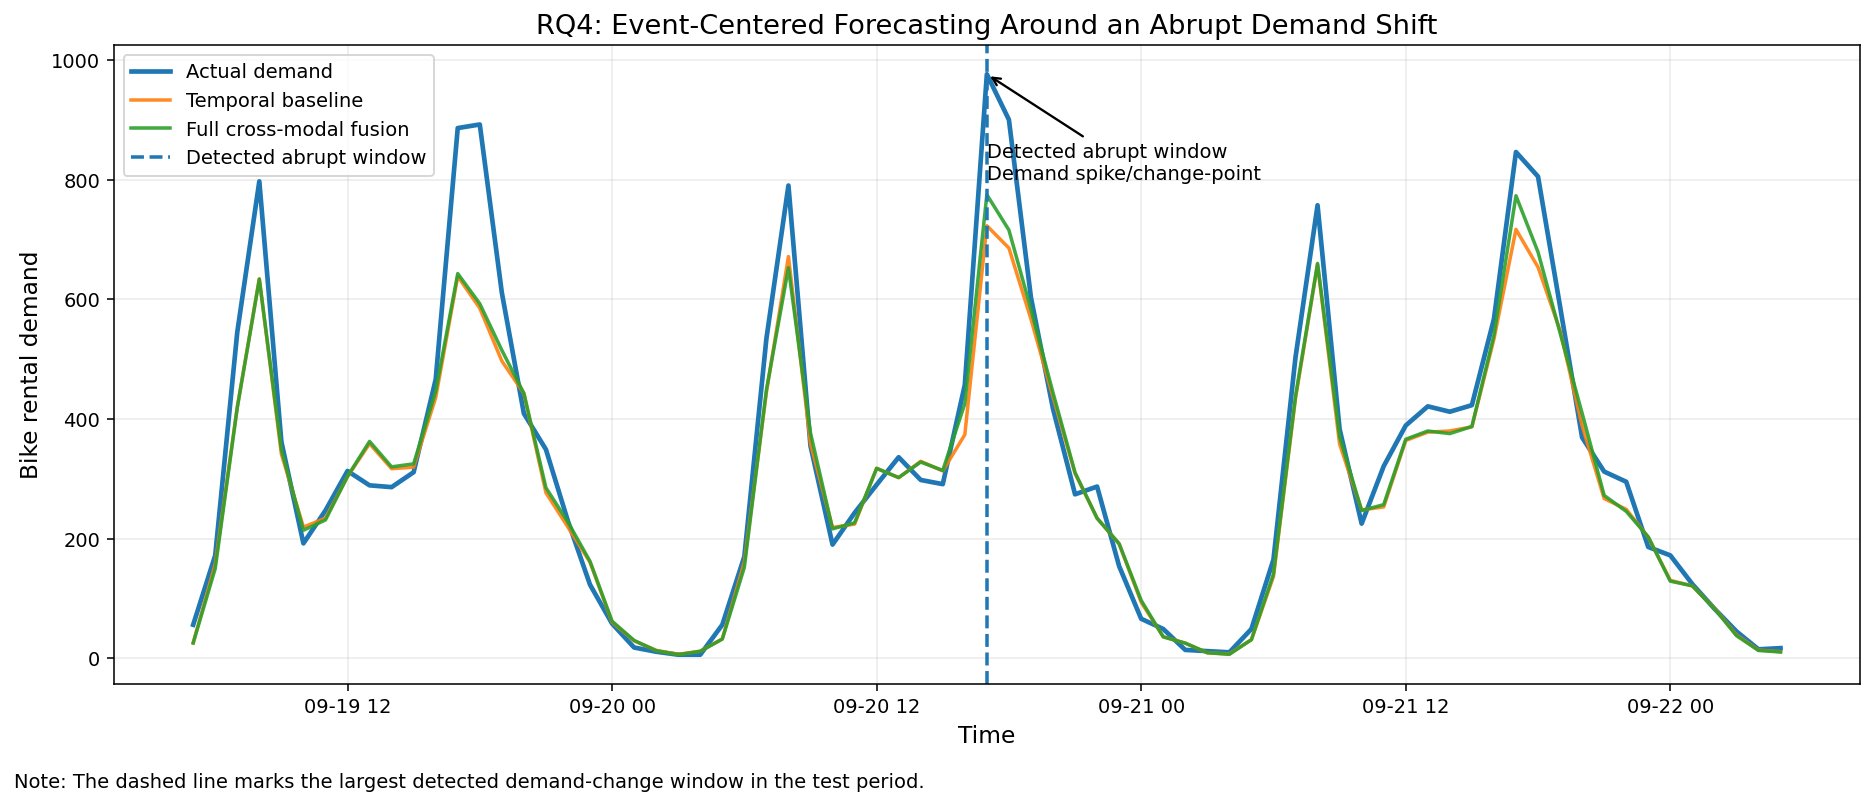

Saved figure: /kaggle/working/urban_demand_RQ4_outputs/figures_pdf/RQ4_Figure_2_shock_scenario_wape_thesis_ready.pdf


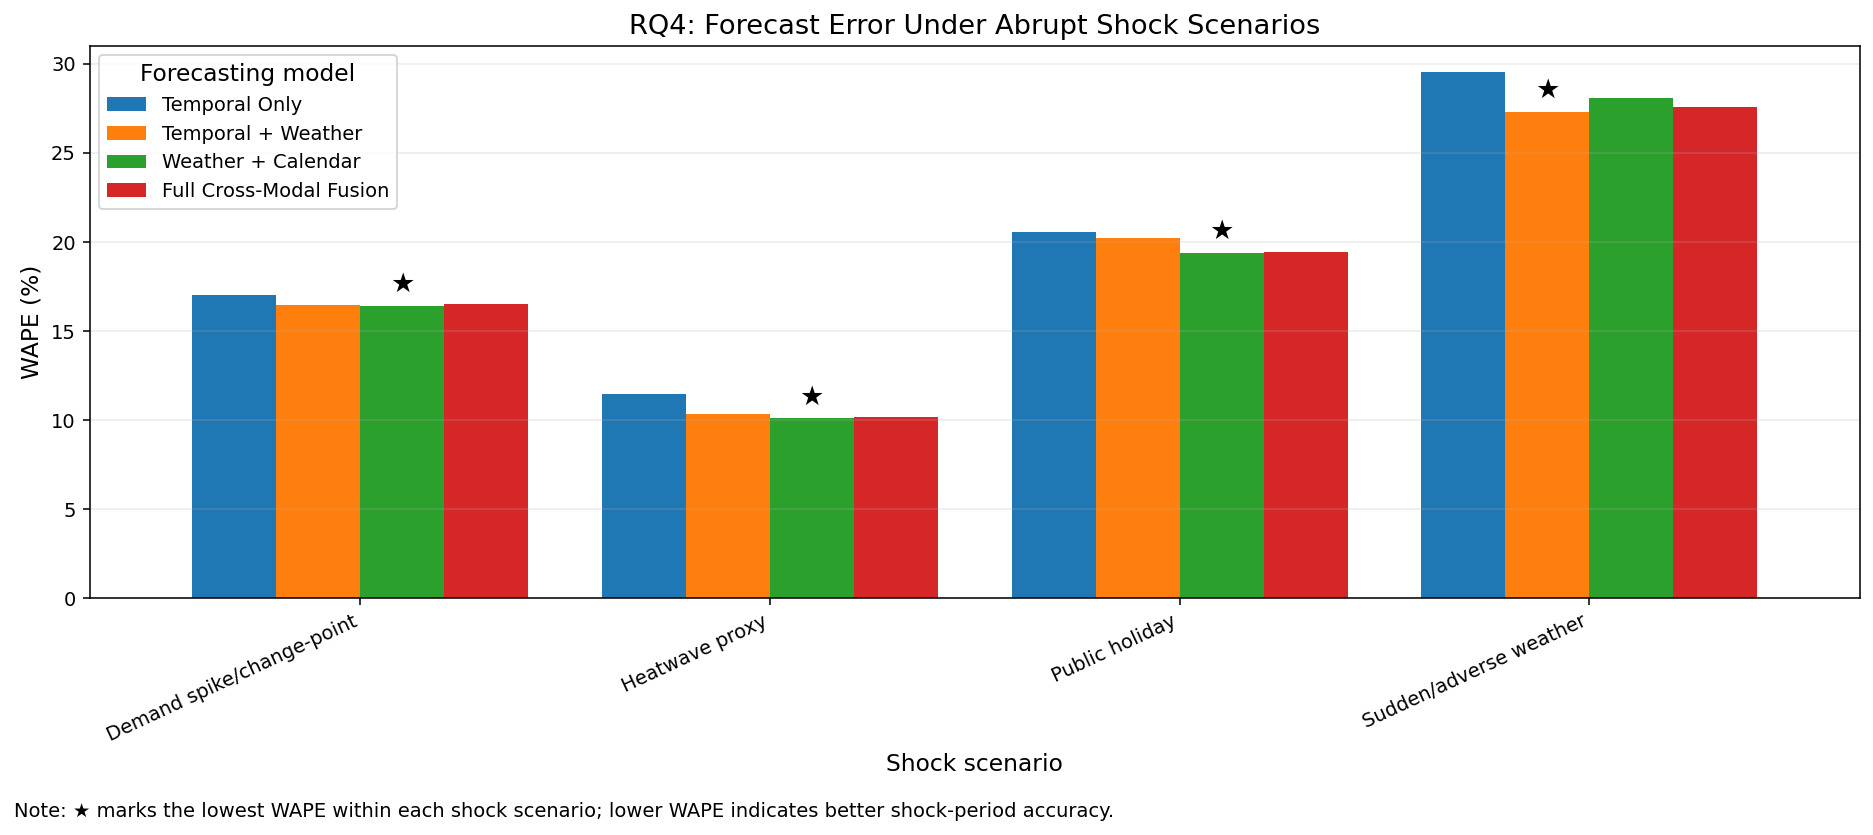

Saved table: /kaggle/working/urban_demand_RQ4_outputs/tables_csv/RQ4_Table_4_lead_time_robustness_supporting_table_thesis_ready.csv


,Lead Time,Model,Shock Samples,RMSE,MAE,WAPE (%),Peak-MAE,Temporal Baseline RMSE,RMSE Gain vs Temporal Only (%),Gain Interpretation
0,1,Temporal Only,259,309.043807,292.216073,54.081606,458.063597,309.043807,0.000000,Worse than or equal to temporal baseline
1,1,Temporal + Weather,259,306.720416,290.368789,53.739722,450.158841,309.043807,0.751800,Improvement over temporal baseline
2,1,Weather + Calendar,259,304.426943,288.830894,53.455097,439.996069,309.043807,1.493919,Improvement over temporal baseline
3,1,Full Cross-Modal Fusion,259,303.577443,287.967051,53.295222,439.891745,309.043807,1.768799,Improvement over temporal baseline
4,3,Temporal Only,259,461.681843,414.420072,76.698393,623.338872,461.681843,0.000000,Worse than or equal to temporal baseline
5,3,Temporal + Weather,259,461.339046,413.371915,76.504406,621.166645,461.681843,0.074250,Improvement over temporal baseline
6,3,Weather + Calendar,259,461.112237,412.608898,76.363191,619.933002,461.681843,0.123376,Improvement over temporal baseline
7,3,Full Cross-Modal Fusion,259,461.457511,412.982561,76.432347,622.093791,461.681843,0.048590,Improvement over temporal baseline
8,6,Temporal Only,259,489.575340,449.317303,83.156964,692.304228,489.575340,0.000000,Worse than or equal to temporal baseline
9,6,Temporal + Weather,259,489.143948,449.021065,83.102138,688.605867,489.575340,0.088116,Improvement over temporal baseline


Saved figure: /kaggle/working/urban_demand_RQ4_outputs/figures_pdf/RQ4_Figure_3_lead_time_robustness_gain_thesis_ready.pdf


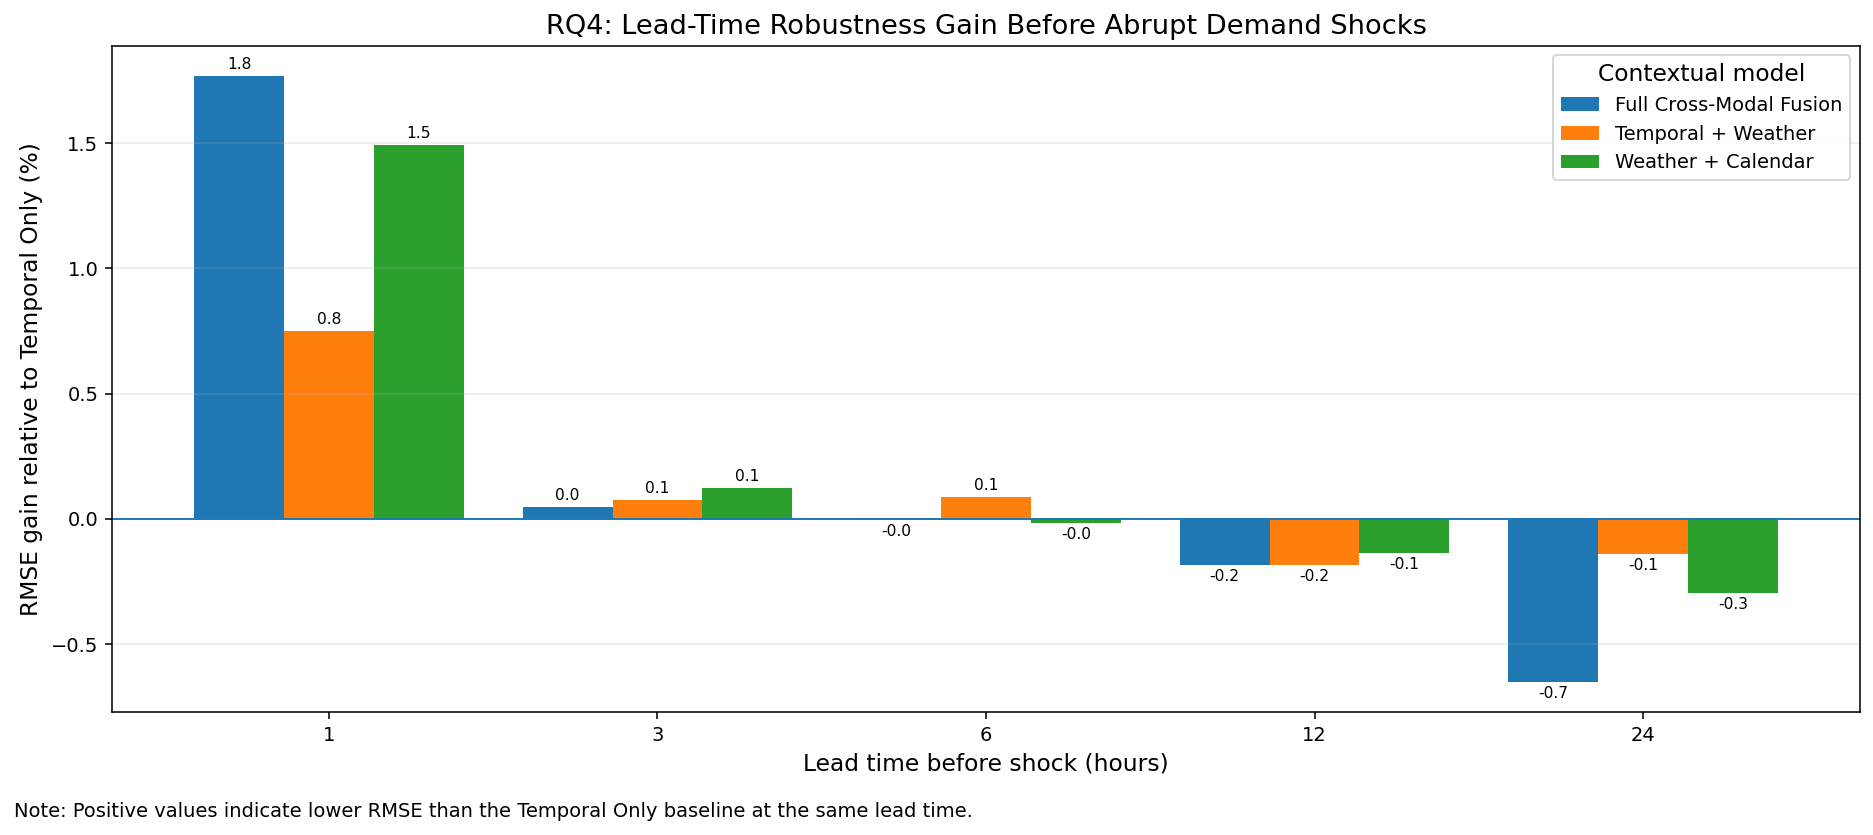

Saved figure: /kaggle/working/urban_demand_RQ4_outputs/figures_pdf/RQ4_Figure_4_change_point_peak_detection_thesis_ready.pdf


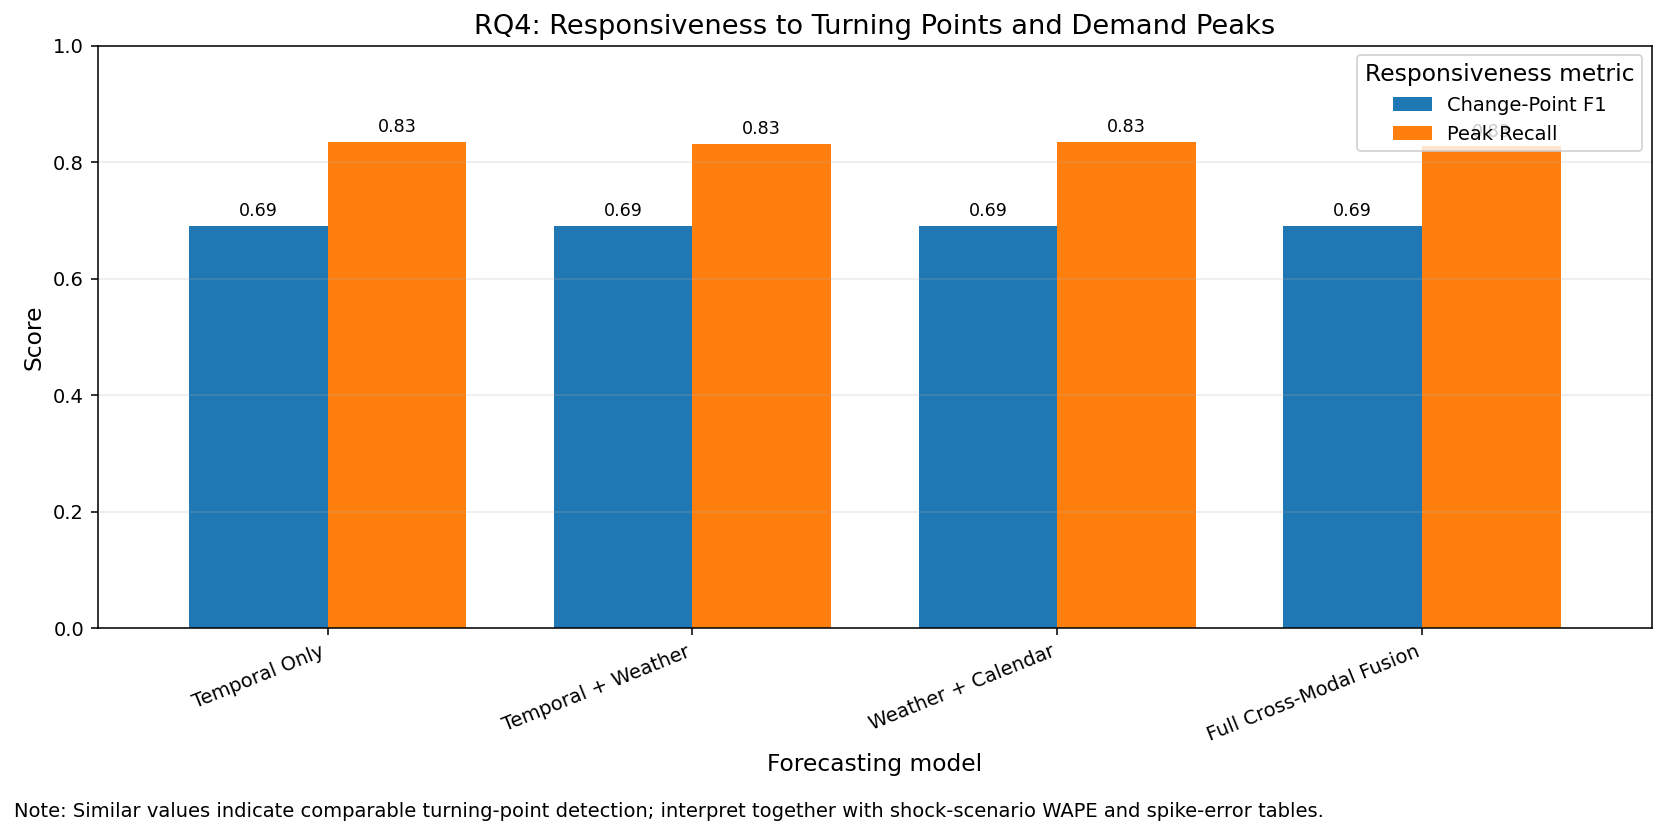


Thesis-safe RQ4 conclusion:
Contextual models improve robustness for several abrupt demand-shift scenarios, but the best-performing modality combination is shock-specific. Therefore, the RQ4 result should be framed as evidence for contextual robustness and adaptive modality usefulness, not as universal dominance of the full cross-modal fusion model.


In [5]:

# ============================================================
# RQ4: Abrupt demand shifts from weather, holiday and demand-spike events
# Thesis-ready version: safe interpretation, readable figures, corrected tables.
# Produces 4 PDF figures + 3 CSV tables.
# ============================================================
section('RQ4 — Thesis-ready abrupt demand-shift responsiveness analysis')

variants = ['Temporal Only', 'Temporal + Weather', 'Weather + Calendar', 'Full Cross-Modal Fusion']
perf, preds, models = evaluate_variants(variants=variants, model_name='rf')

# ------------------------------------------------------------
# 1) Define shock/event windows transparently from the UCI data
# ------------------------------------------------------------
TEST2 = TEST.copy().reset_index(drop=True)
TEST2['abs_change'] = TEST2[TARGET].diff().abs().fillna(0)
change_thr = TEST2['abs_change'].quantile(0.90)
peak_thr = TEST2[TARGET].quantile(0.90)

# Priority order matters: adverse weather and holidays are explicit contextual shocks;
# remaining large changes are treated as demand-spike/change-point events.
TEST2['shock_type'] = np.select(
    [
        TEST2['weathersit'].ge(3),
        TEST2['holiday'].eq(1),
        TEST2['abs_change'].ge(change_thr),
        TEST2['temp'].ge(TEST2['temp'].quantile(0.90))
    ],
    [
        'Sudden/adverse weather',
        'Public holiday',
        'Demand spike/change-point',
        'Heatwave proxy'
    ],
    default='Normal'
)

shock_order = ['Demand spike/change-point', 'Heatwave proxy', 'Public holiday', 'Sudden/adverse weather']
shock_types = [s for s in shock_order if (TEST2['shock_type'] == s).sum() > 0]
print('Shock windows detected:')
display(TEST2['shock_type'].value_counts().rename_axis('Shock Scenario').reset_index(name='Samples'))

# ------------------------------------------------------------
# 2) Table 1: shock-scenario forecasting accuracy with best-model markers
# ------------------------------------------------------------
rows = []
for st in shock_types:
    mask = TEST2['shock_type'].eq(st).values
    for name, pred in preds.items():
        m = metrics(TEST2.loc[mask, TARGET], pred[mask])
        rows.append({'Shock Scenario': st, 'Samples': int(mask.sum()), 'Model': name, **m})
shock_perf = pd.DataFrame(rows)

# Add best model per scenario using WAPE (lower is better)
best_idx = shock_perf.groupby('Shock Scenario')['WAPE (%)'].idxmin()
best_map = shock_perf.loc[best_idx].set_index('Shock Scenario')['Model'].to_dict()
shock_perf['Best Model by WAPE'] = shock_perf['Shock Scenario'].map(best_map)
shock_perf['Best in Scenario'] = shock_perf.apply(lambda r: 'Yes' if r['Model'] == r['Best Model by WAPE'] else 'No', axis=1)

scenario_notes = {
    'Demand spike/change-point': 'Abrupt demand spikes are handled best by the lowest-WAPE contextual configuration; interpret as responsiveness to nonstationary demand.',
    'Heatwave proxy': 'High-temperature periods test weather sensitivity and outdoor-mobility effects.',
    'Public holiday': 'Holiday windows test whether calendar and weather-calendar combinations improve distorted routine demand.',
    'Sudden/adverse weather': 'Adverse-weather windows test whether meteorological features reduce shock-period forecast error.'
}
shock_perf['Thesis-safe interpretation'] = shock_perf['Shock Scenario'].map(scenario_notes)
shock_perf = shock_perf.sort_values(['Shock Scenario', 'WAPE (%)']).reset_index(drop=True)
save_table(shock_perf, 'RQ4_Table_1_forecast_accuracy_under_shock_scenarios_thesis_ready')

# ------------------------------------------------------------
# 3) Table 2: change-point and peak responsiveness metrics
# ------------------------------------------------------------
true_cp = TEST2['abs_change'].ge(change_thr).values
peak_true = TEST2[TARGET].values >= peak_thr
rows = []
for name, pred in preds.items():
    pred_change = np.abs(pd.Series(pred).diff().fillna(0).values)
    pred_cp = pred_change >= np.quantile(pred_change, 0.90)

    tp = np.sum(true_cp & pred_cp)
    fp = np.sum(~true_cp & pred_cp)
    fn = np.sum(true_cp & ~pred_cp)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    pred_peak = pred >= np.quantile(pred, 0.90)
    peak_recall = np.sum(peak_true & pred_peak) / (np.sum(peak_true) + 1e-9)
    extreme_mae = metrics(TEST2.loc[peak_true, TARGET], pred[peak_true])['MAE']

    rows.append({
        'Model': name,
        'Change-Point Precision': precision,
        'Change-Point Recall': recall,
        'Change-Point F1': f1,
        'Peak Recall': peak_recall,
        'Extreme Spike MAE': extreme_mae
    })
cp_df = pd.DataFrame(rows)

# Mark best metrics: higher is better for F1/recall, lower is better for MAE
cp_df['Best Change-Point F1'] = np.where(cp_df['Change-Point F1'].eq(cp_df['Change-Point F1'].max()), 'Yes', 'No')
cp_df['Best Peak Recall'] = np.where(cp_df['Peak Recall'].eq(cp_df['Peak Recall'].max()), 'Yes', 'No')
cp_df['Best Extreme Spike MAE'] = np.where(cp_df['Extreme Spike MAE'].eq(cp_df['Extreme Spike MAE'].min()), 'Yes', 'No')
cp_df['Thesis-safe interpretation'] = 'Change-point and peak metrics are similar across models; emphasize contextual robustness rather than universal dominance.'
cp_df = cp_df.sort_values('Extreme Spike MAE').reset_index(drop=True)
save_table(cp_df, 'RQ4_Table_2_change_point_and_peak_detection_thesis_ready')

# ------------------------------------------------------------
# 4) Table 3: top abrupt event windows with contextual labels
# ------------------------------------------------------------
event_windows = TEST2.sort_values('abs_change', ascending=False).head(20).copy()
event_windows['Event Rank'] = np.arange(1, len(event_windows) + 1)
event_windows['Previous Demand'] = event_windows[TARGET].shift(1)
event_windows['Event Context'] = np.select(
    [event_windows['weathersit'].ge(3), event_windows['holiday'].eq(1), event_windows['temp'].ge(TEST2['temp'].quantile(0.90))],
    ['Adverse weather', 'Holiday', 'High temperature'],
    default='Demand spike/change-point'
)
event_windows = event_windows[[
    'Event Rank', 'datetime', 'cnt', 'Previous Demand', 'abs_change',
    'weathersit', 'holiday', 'temp', 'hum', 'windspeed', 'regime', 'shock_type', 'Event Context'
]]
save_table(event_windows, 'RQ4_Table_3_top_abrupt_event_windows_thesis_ready')

# ------------------------------------------------------------
# 5) Figure 1: event-centered demand shift with annotation
# ------------------------------------------------------------
idx = int(TEST2['abs_change'].idxmax())
lo, hi = max(0, idx - 36), min(len(TEST2), idx + 37)
event_time = TEST2['datetime'].iloc[idx]
shock_label = TEST2['shock_type'].iloc[idx]

plt.figure(figsize=(13.5, 5.6))
plt.plot(TEST2['datetime'].iloc[lo:hi], TEST2[TARGET].iloc[lo:hi], label='Actual demand', linewidth=2.4)
plt.plot(TEST2['datetime'].iloc[lo:hi], preds['Temporal Only'][lo:hi], label='Temporal baseline', linewidth=1.8, alpha=0.9)
plt.plot(TEST2['datetime'].iloc[lo:hi], preds['Full Cross-Modal Fusion'][lo:hi], label='Full cross-modal fusion', linewidth=1.8, alpha=0.9)
plt.axvline(event_time, linestyle='--', linewidth=1.8, label='Detected abrupt window')
plt.annotate(
    f'Detected abrupt window\n{shock_label}',
    xy=(event_time, TEST2[TARGET].iloc[idx]),
    xytext=(event_time, TEST2[TARGET].iloc[lo:hi].max() * 0.82),
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=10,
    ha='left'
)
plt.title('RQ4: Event-Centered Forecasting Around an Abrupt Demand Shift')
plt.ylabel('Bike rental demand')
plt.xlabel('Time')
plt.legend(loc='upper left', frameon=True)
plt.grid(alpha=0.25)
plt.figtext(0.01, -0.02, 'Note: The dashed line marks the largest detected demand-change window in the test period.', fontsize=10)
save_fig('RQ4_Figure_1_event_centered_demand_shift_thesis_ready')

# ------------------------------------------------------------
# 6) Figure 2: WAPE under shock scenarios with best model markers
# ------------------------------------------------------------
wape_piv = shock_perf.pivot_table(index='Shock Scenario', columns='Model', values='WAPE (%)', aggfunc='first').reindex(shock_types)
ax = wape_piv[variants].plot(kind='bar', figsize=(13.5, 5.8), width=0.82)
plt.title('RQ4: Forecast Error Under Abrupt Shock Scenarios')
plt.ylabel('WAPE (%)')
plt.xlabel('Shock scenario')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.legend(title='Forecasting model', frameon=True)

# Add stars on the lowest-WAPE bar in each shock scenario
for i, scenario in enumerate(wape_piv.index):
    vals = wape_piv.loc[scenario, variants]
    best_model = vals.idxmin()
    best_j = variants.index(best_model)
    patch_index = best_j * len(wape_piv.index) + i
    patch = ax.patches[patch_index]
    ax.text(
        patch.get_x() + patch.get_width()/2,
        patch.get_height() + max(0.3, wape_piv.max().max()*0.015),
        '★',
        ha='center', va='bottom', fontsize=14, fontweight='bold'
    )
plt.figtext(0.01, -0.02, 'Note: ★ marks the lowest WAPE within each shock scenario; lower WAPE indicates better shock-period accuracy.', fontsize=10)
save_fig('RQ4_Figure_2_shock_scenario_wape_thesis_ready')

# ------------------------------------------------------------
# 7) Figure 3: lead-time robustness redesigned as RMSE gain vs Temporal Only
#    This avoids overlapping raw RMSE lines and is more informative.
# ------------------------------------------------------------
lead_rows = []
cp_indices = np.where(true_cp)[0]
lead_times = [1, 3, 6, 12, 24]
for lead in lead_times:
    valid = cp_indices[cp_indices - lead >= 0]
    if len(valid) == 0:
        continue
    for name, pred in preds.items():
        y = TEST2[TARGET].values[valid]
        p = pred[valid - lead]
        lead_rows.append({'Lead Time': lead, 'Model': name, 'Shock Samples': len(valid), **metrics(y, p)})
lead_df = pd.DataFrame(lead_rows)

# Calculate gain against Temporal Only at each lead time; positive values mean lower RMSE.
temporal_rmse = lead_df[lead_df['Model'].eq('Temporal Only')].set_index('Lead Time')['RMSE'].to_dict()
lead_df['Temporal Baseline RMSE'] = lead_df['Lead Time'].map(temporal_rmse)
lead_df['RMSE Gain vs Temporal Only (%)'] = 100 * (lead_df['Temporal Baseline RMSE'] - lead_df['RMSE']) / lead_df['Temporal Baseline RMSE']
lead_df['Gain Interpretation'] = np.where(lead_df['RMSE Gain vs Temporal Only (%)'] > 0, 'Improvement over temporal baseline', 'Worse than or equal to temporal baseline')
save_table(lead_df, 'RQ4_Table_4_lead_time_robustness_supporting_table_thesis_ready')

plot_df = lead_df[~lead_df['Model'].eq('Temporal Only')].pivot(index='Lead Time', columns='Model', values='RMSE Gain vs Temporal Only (%)').reindex(lead_times)
ax = plot_df.plot(kind='bar', figsize=(13.5, 5.8), width=0.82)
plt.axhline(0, linewidth=1)
plt.title('RQ4: Lead-Time Robustness Gain Before Abrupt Demand Shocks')
plt.ylabel('RMSE gain relative to Temporal Only (%)')
plt.xlabel('Lead time before shock (hours)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.25)
plt.legend(title='Contextual model', frameon=True)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)
plt.figtext(0.01, -0.02, 'Note: Positive values indicate lower RMSE than the Temporal Only baseline at the same lead time.', fontsize=10)
save_fig('RQ4_Figure_3_lead_time_robustness_gain_thesis_ready')

# ------------------------------------------------------------
# 8) Figure 4: responsiveness metrics with value labels
# ------------------------------------------------------------
cp_plot = cp_df.set_index('Model').reindex(variants)[['Change-Point F1', 'Peak Recall']]
ax = cp_plot.plot(kind='bar', figsize=(12, 5.8), width=0.76)
plt.title('RQ4: Responsiveness to Turning Points and Demand Peaks')
plt.ylabel('Score')
plt.xlabel('Forecasting model')
plt.xticks(rotation=22, ha='right')
plt.ylim(0, max(1.0, cp_plot.values.max() * 1.18))
plt.grid(axis='y', alpha=0.25)
plt.legend(title='Responsiveness metric', frameon=True)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=3)
plt.figtext(0.01, -0.02, 'Note: Similar values indicate comparable turning-point detection; interpret together with shock-scenario WAPE and spike-error tables.', fontsize=10)
save_fig('RQ4_Figure_4_change_point_peak_detection_thesis_ready')

# ------------------------------------------------------------
# 9) Printed thesis-safe conclusion for direct use in results writing
# ------------------------------------------------------------
print('\nThesis-safe RQ4 conclusion:')
print('Contextual models improve robustness for several abrupt demand-shift scenarios, but the best-performing modality combination is shock-specific. Therefore, the RQ4 result should be framed as evidence for contextual robustness and adaptive modality usefulness, not as universal dominance of the full cross-modal fusion model.')



In [6]:

# ============================================================
# Final export: ZIP all tables and figures from this RQ
# ============================================================
zip_outputs()


Final ZIP created: /kaggle/working/urban_demand_RQ4_outputs.zip


PosixPath('/kaggle/working/urban_demand_RQ4_outputs.zip')